In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



weight (slope): [9.7417925]
Bias (Intercept):  20.641339312727283
MSE: 52.10296690837972
R2 Score 0.8831152500823761


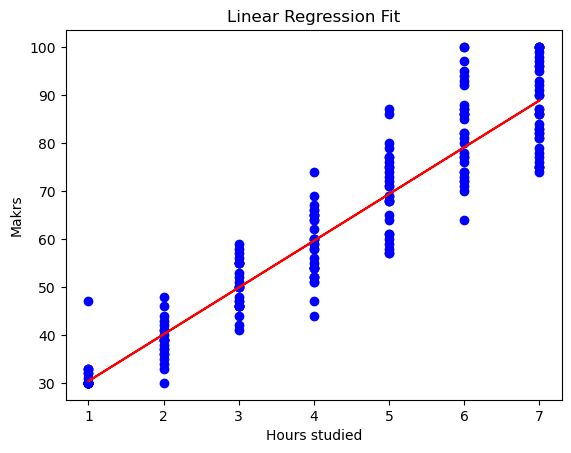

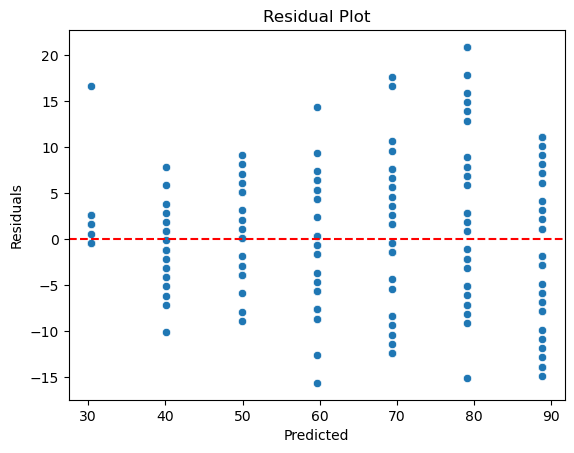

In [5]:
df = pd.read_csv(r"C:\Users\Hp\OneDrive\Desktop\AIML\krish_naik\Machine_Learning\student_report.csv")

#the below code is for creating the new column and create a updated dataset 
df['Hours'] = np.random.randint(1, 8, size=len(df))
base_marks = 20
efficiency = np.random.uniform(8, 12, size=len(df))   # every student different IQ/learning power
noise = np.random.normal(0, 5, size=len(df))          # real-life randomness
df['total_Marks'] = base_marks + (df['Hours'] * efficiency) + noise
df['total_Marks'] = df['total_Marks'].clip(30, 100).astype(int)
df.to_csv("student_report.csv", index=False)
# print("Dataset Updated Successfully!")


# df.head()
# df.info()
df.isnull().sum()

X = df[['Hours']]
y= df['total_Marks']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()

model.fit(X_train, y_train)

print("weight (slope):", model.coef_)
print("Bias (Intercept): ", model.intercept_)

#prediction

y_pred = model.predict(X_test)

model.predict(pd.DataFrame({'Hours':[6]}))

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
r2 = r2_score(y_test, y_pred)
print("R2 Score", r2)


#vizualization


plt.scatter(X_test['Hours'], y_test, color='blue')
plt.plot(X_test['Hours'], y_pred, color='red')
plt.xlabel("Hours studied")
plt.ylabel("Makrs")
plt.title("Linear Regression Fit")
plt.show()



residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
